# Vodafone Music Subscription Prediction

## Sprint 2 — Deep Exploratory Data Analysis

**Goal of this notebook:**

Go beyond basic statistics — explore feature distributions by target class,
identify interaction patterns, rank features by predictive power, and generate
concrete hypotheses for feature engineering.

**Notebook outline:**
1. Setup & Data Loading
2. Feature Groups Overview
3. Univariate Analysis — Top Signal Features
4. Bivariate Analysis — Distributions by Target Class
5. Temporal Features Analysis (m1 / m2 / m3 trends)
6. Categorical Features Analysis
7. Mutual Information Ranking
8. Correlation Heatmap — Top Features
9. Class Imbalance Deep Dive
10. EDA Summary & Feature Engineering Hypotheses

### 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import mannwhitneyu, pointbiserialr
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

DATA_PATH = '../data/processed/train_cleaned.csv'
df = pd.read_csv(DATA_PATH)

print('Shape:', df.shape)
print('Target distribution:')
print(df['target'].value_counts(normalize=True).round(4))

# Split by target for convenient comparison
df0 = df[df['target'] == 0]
df1 = df[df['target'] == 1]
print(f'\nClass 0: {len(df0):,}  |  Class 1: {len(df1):,}')

Shape: (70000, 430)
Target distribution:
target
0    0.9243
1    0.0757
Name: proportion, dtype: float64

Class 0: 64,699  |  Class 1: 5,301


### 2. Feature Groups Overview

We categorise the 430 features into groups based on naming conventions
to understand what types of signal we have available.


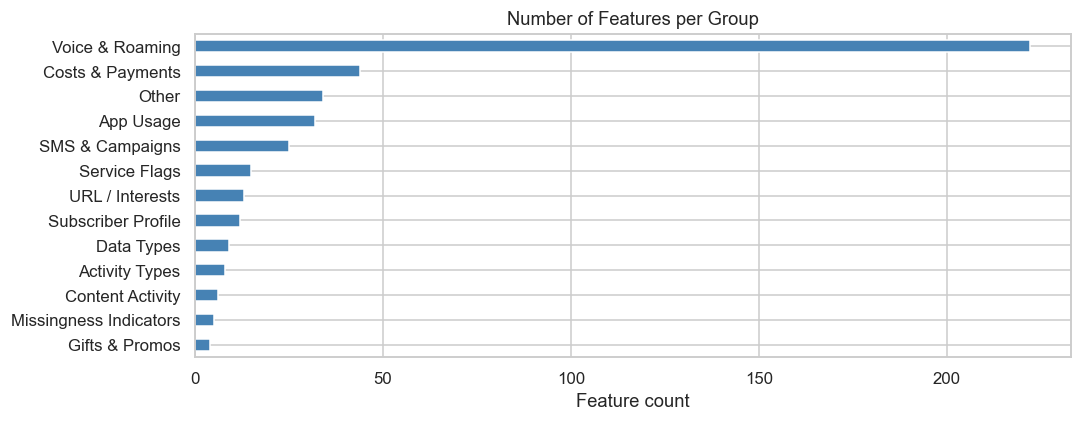

Voice & Roaming           222
Costs & Payments           44
Other                      34
App Usage                  32
SMS & Campaigns            25
Service Flags              15
URL / Interests            13
Subscriber Profile         12
Data Types                  9
Activity Types              8
Content Activity            6
Missingness Indicators      5
Gifts & Promos              4


In [2]:
feature_cols = [c for c in df.columns if c != 'target']

def classify_group(col):
    c = col.lower()
    if c.endswith('__was_missing'):          return 'Missingness Indicators'
    if c.startswith('content_'):             return 'Content Activity'
    if c.startswith('vol_app') or c.startswith('count_app'): return 'App Usage'
    if c.startswith('count_url'):            return 'URL / Interests'
    if c.startswith('count_sms') or c.startswith('rr_'):     return 'SMS & Campaigns'
    if c.startswith('count_act') or c.startswith('rr_act'):  return 'Activity Types'
    if c.startswith('count_gift') or c.startswith('rr_gift'): return 'Gifts & Promos'
    if 'voice' in c or 'sms_roam' in c:     return 'Voice & Roaming'
    if 'data_type' in c:                     return 'Data Types'
    if any(k in c for k in ['cost','paym','balance','income','all_cost']): return 'Costs & Payments'
    if c in ['lt','days_exp','sim_count','block_flag','tp_flag',
              'device_type','manufacturer_category','os_category',
              'is_obl_center','service_p_flag_m1','service_p_flag_m2','service_p_flag_m3']: return 'Subscriber Profile'
    if 'service' in c:                       return 'Service Flags'
    return 'Other'

group_map = {c: classify_group(c) for c in feature_cols}
group_counts = pd.Series(group_map).value_counts()

plt.figure(figsize=(10, 4))
group_counts.sort_values().plot(kind='barh', color='steelblue')
plt.title('Number of Features per Group')
plt.xlabel('Feature count')
plt.tight_layout()
plt.show()

print(group_counts.to_string())

### 3. Univariate Analysis — Top Signal Features

We compute **point-biserial correlation** (correct metric for continuous feature vs binary target)
and rank all features. Then visualise the top-20.


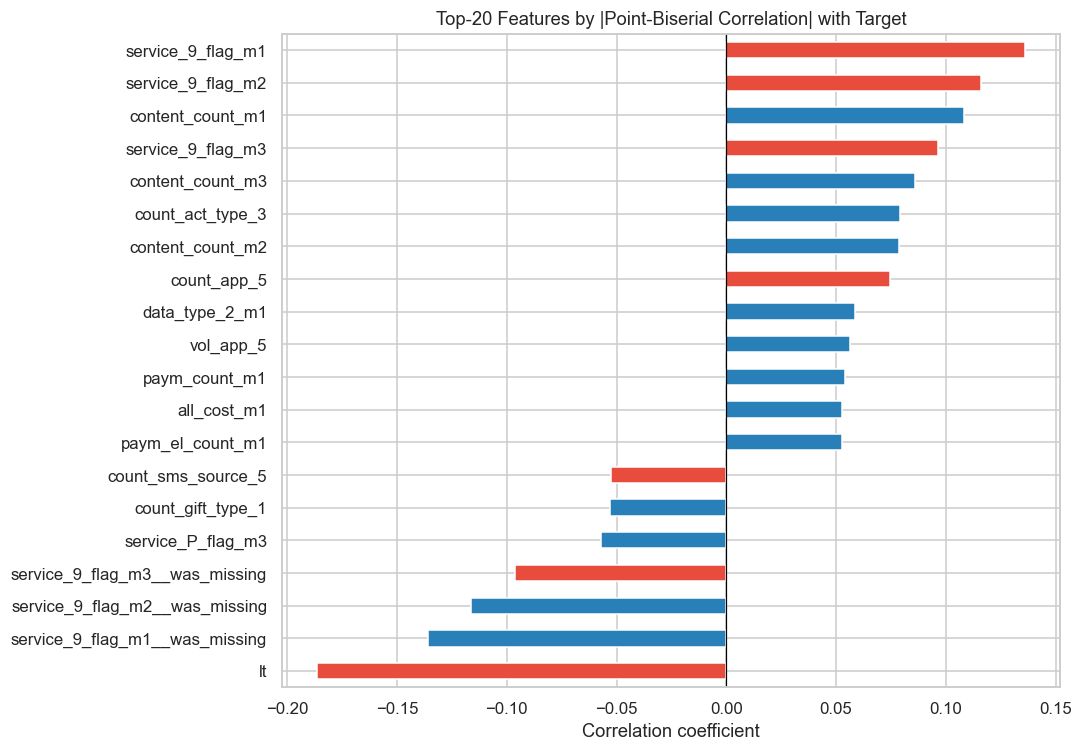

Top 20 features (absolute correlation):
lt                               -0.186401
service_9_flag_m1__was_missing   -0.135877
service_9_flag_m1                 0.135877
service_9_flag_m2__was_missing   -0.116279
service_9_flag_m2                 0.116279
content_count_m1                  0.108292
service_9_flag_m3                 0.096357
service_9_flag_m3__was_missing   -0.096357
content_count_m3                  0.086058
count_act_type_3                  0.079204
content_count_m2                  0.078608
count_app_5                       0.074512
data_type_2_m1                    0.058852
service_P_flag_m3                -0.057147
vol_app_5                         0.056170
paym_count_m1                     0.054097
count_gift_type_1                -0.053084
all_cost_m1                       0.052700
paym_el_count_m1                  0.052631
count_sms_source_5               -0.052608


In [3]:
# Point-biserial correlation for all numeric features
pb_corrs = {}
for col in feature_cols:
    try:
        r, _ = pointbiserialr(df[col], df['target'])
        pb_corrs[col] = r
    except Exception:
        pass

pb_series = pd.Series(pb_corrs).dropna().sort_values(key=abs, ascending=False)

top20 = pb_series.head(20)
colors = ['#e74c3c' if v < 0 else '#2980b9' for v in top20.values]

plt.figure(figsize=(10, 7))
top20.sort_values().plot(kind='barh', color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top-20 Features by |Point-Biserial Correlation| with Target')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

print('Top 20 features (absolute correlation):')
print(pb_series.head(20).to_string())

### 4. Bivariate Analysis — Distributions by Target Class

For the top-12 features by correlation we compare distributions between
subscribers (target=1) and non-subscribers (target=0).
We use **KDE plots** and **boxplots**, and run a **Mann-Whitney U test**
to confirm statistical significance.


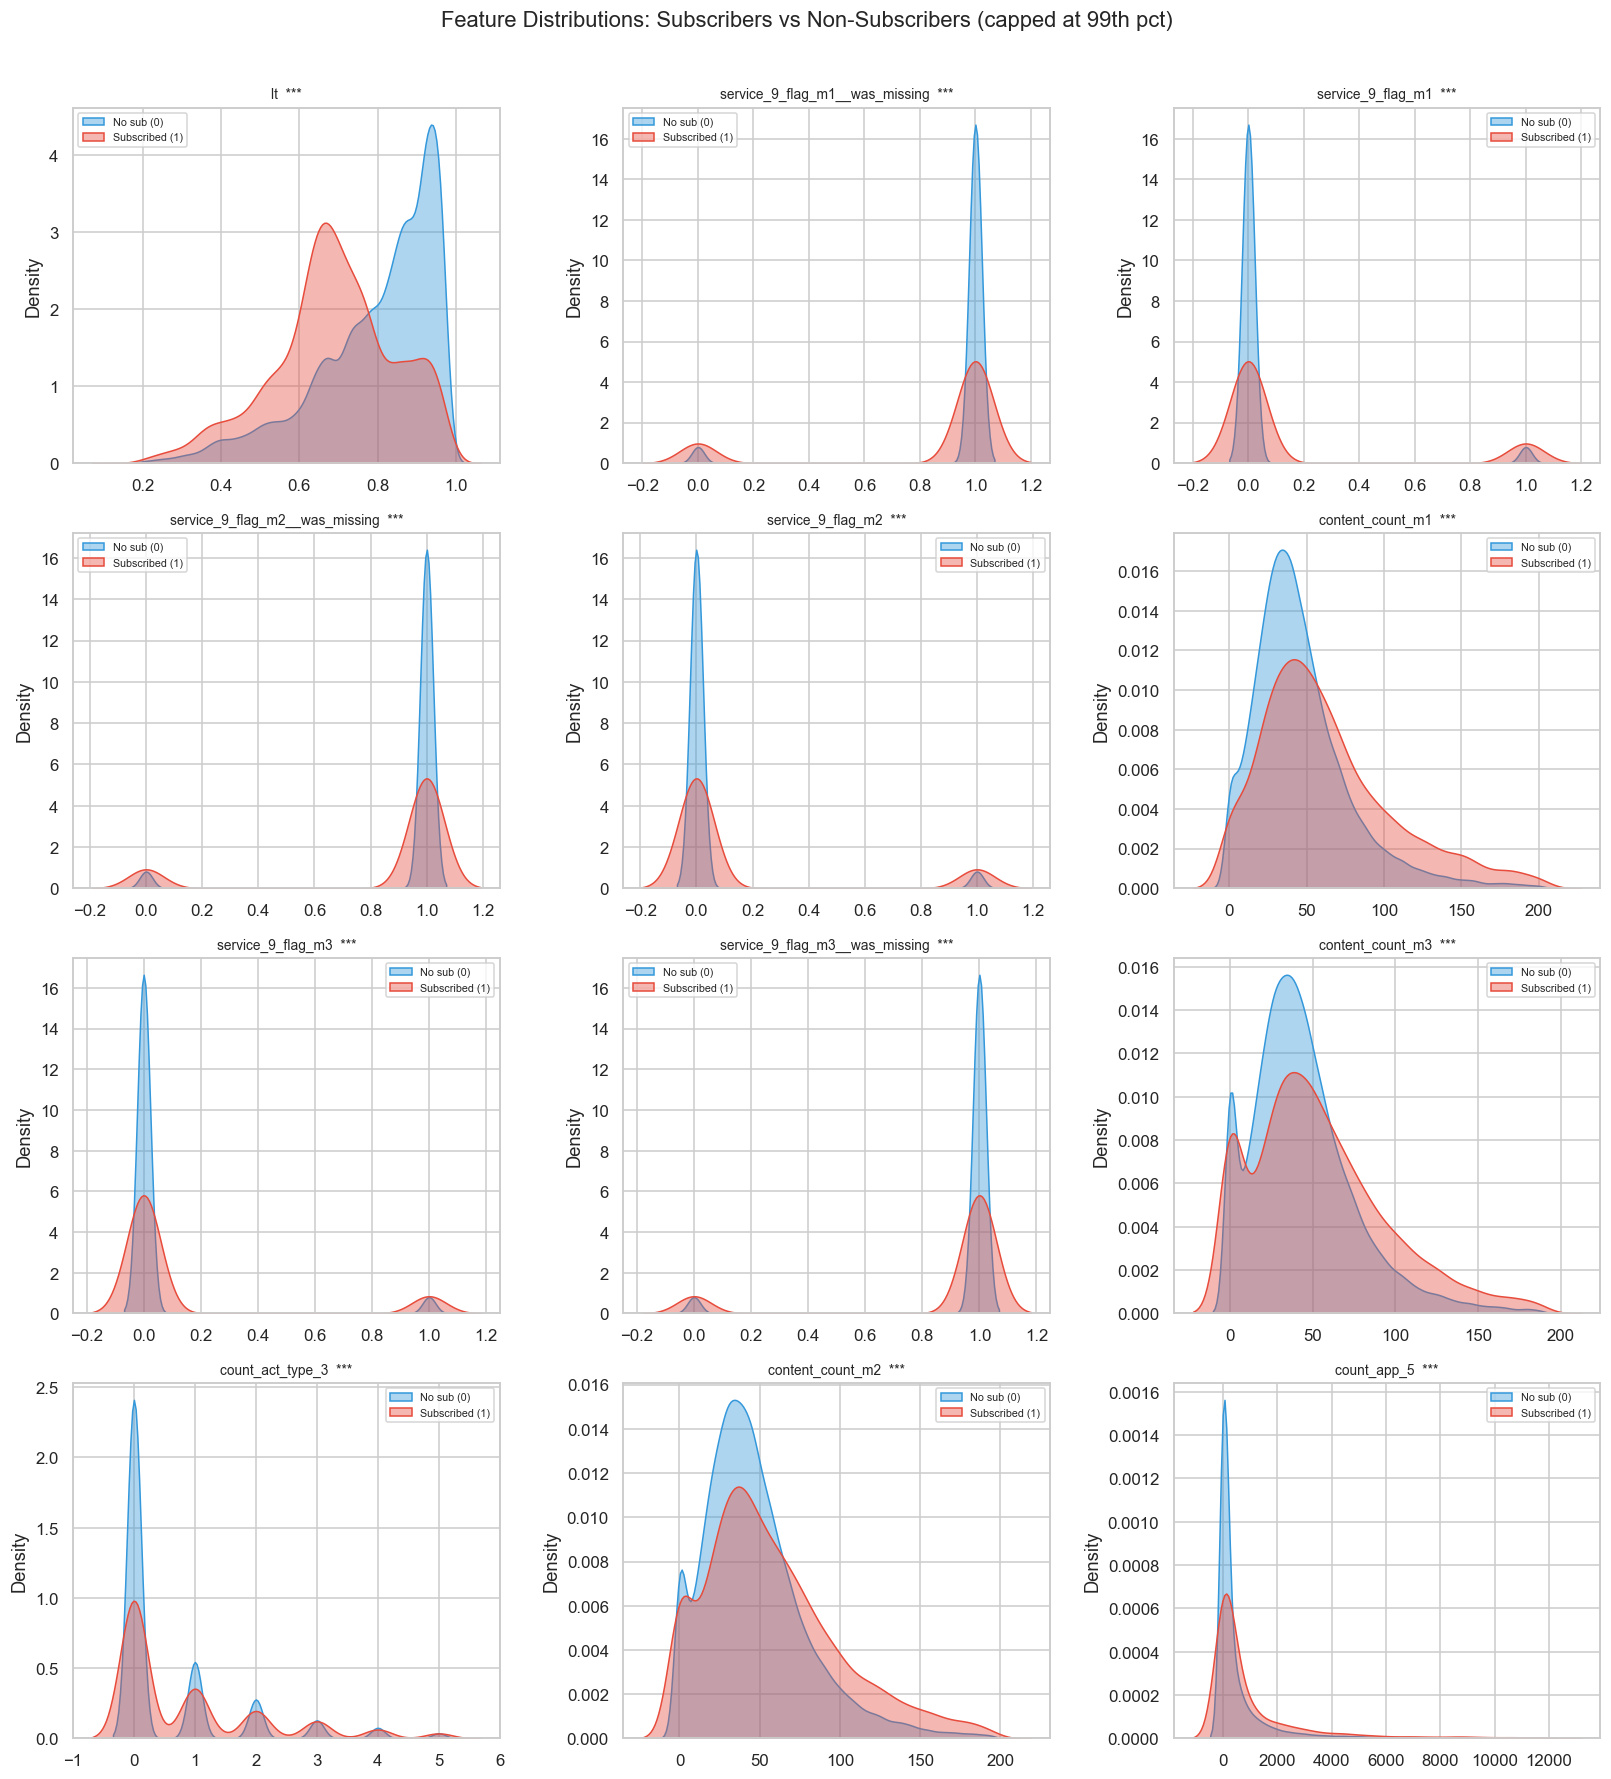


Mann-Whitney U Test Results:
                       feature       p_value significance  mean_class0  mean_class1
                            lt  0.000000e+00          ***     0.797040     0.686682
service_9_flag_m1__was_missing 5.180094e-283          ***     0.954250     0.837578
             service_9_flag_m1 5.180094e-283          ***     0.045750     0.162422
service_9_flag_m2__was_missing 7.846232e-208          ***     0.952735     0.852669
             service_9_flag_m2 7.846232e-208          ***     0.047265     0.147331
              content_count_m1 1.952616e-201          ***    48.567088    71.294473
             service_9_flag_m3 2.321637e-143          ***     0.045998     0.126957
service_9_flag_m3__was_missing 2.321637e-143          ***     0.954002     0.873043
              content_count_m3  1.424445e-74          ***    46.029985    61.601585
              count_act_type_3 7.891121e-103          ***     0.590952     0.929447
              content_count_m2  6.819014e-82  

In [4]:
TOP_FEATURES = pb_series.head(12).index.tolist()

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

mw_results = []

for i, col in enumerate(TOP_FEATURES):
    ax = axes[i]
    v0 = df0[col].dropna()
    v1 = df1[col].dropna()

    # Cap at 99th percentile for readable plots
    cap = df[col].quantile(0.99)
    v0c = v0[v0 <= cap]
    v1c = v1[v1 <= cap]

    sns.kdeplot(v0c, ax=ax, label='No sub (0)', fill=True, alpha=0.4, color='#3498db')
    sns.kdeplot(v1c, ax=ax, label='Subscribed (1)', fill=True, alpha=0.4, color='#e74c3c')

    stat, p = mannwhitneyu(v0, v1, alternative='two-sided')
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    mw_results.append({'feature': col, 'p_value': p, 'significance': sig,
                       'mean_class0': v0.mean(), 'mean_class1': v1.mean()})

    ax.set_title(f'{col}  {sig}', fontsize=9)
    ax.set_xlabel('')
    ax.legend(fontsize=7)

plt.suptitle('Feature Distributions: Subscribers vs Non-Subscribers (capped at 99th pct)', y=1.01)
plt.tight_layout()
plt.show()

mw_df = pd.DataFrame(mw_results)
print('\nMann-Whitney U Test Results:')
print(mw_df.to_string(index=False))

### 5. Temporal Features Analysis (m1 / m2 / m3 Trends)

Many features exist in three temporal versions: `_m1` (last month), `_m2` (2 months ago), `_m3` (3 months ago).
We analyse whether the **trend over time** (growing / declining activity) differs between the two classes.


Feature families with all m1/m2/m3 versions: 109


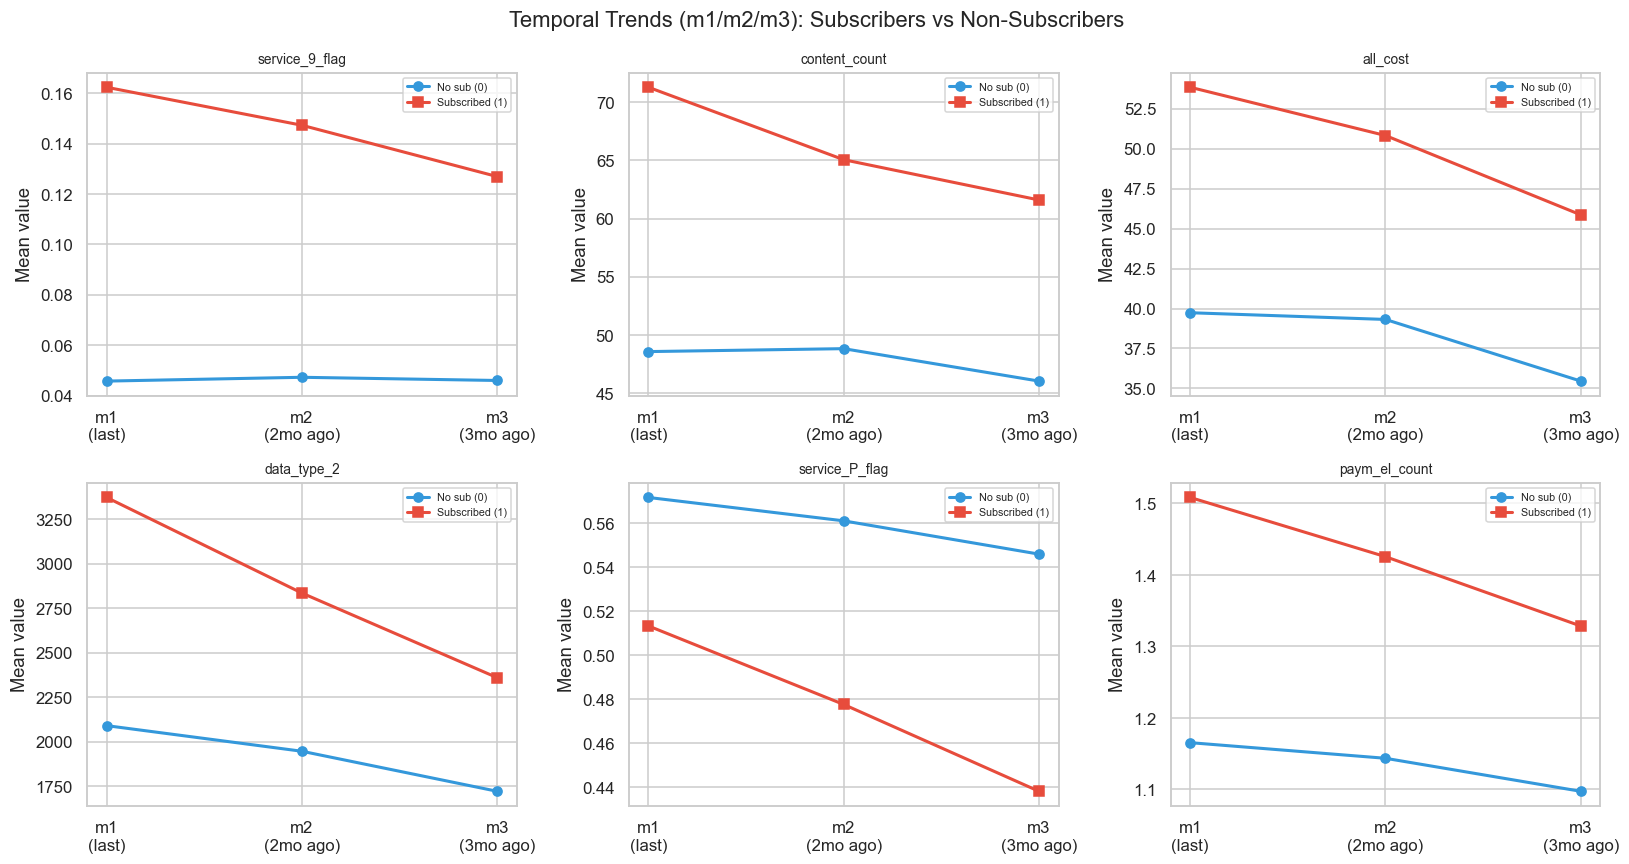

In [5]:
# Find feature families with all 3 temporal versions
import re

def get_base(col):
    return re.sub(r'_m[123]$', '', col)

bases = {}
for col in feature_cols:
    if re.search(r'_m[123]$', col):
        b = get_base(col)
        bases.setdefault(b, []).append(col)

# Keep families where all 3 months present
full_families = {b: sorted(cols) for b, cols in bases.items() if len(cols) == 3}
print(f'Feature families with all m1/m2/m3 versions: {len(full_families)}')

# Pick top-6 families by average point-biserial correlation
family_signal = {}
for b, cols in full_families.items():
    avg_r = np.mean([abs(pb_corrs.get(c, 0)) for c in cols])
    family_signal[b] = avg_r

top_families = sorted(family_signal, key=family_signal.get, reverse=True)[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, base in enumerate(top_families):
    cols = full_families[base]  # [_m1, _m2, _m3] sorted
    months = ['m1\n(last)', 'm2\n(2mo ago)', 'm3\n(3mo ago)']

    means0 = [df0[c].mean() for c in cols]
    means1 = [df1[c].mean() for c in cols]

    ax = axes[i]
    ax.plot(months, means0, 'o-', color='#3498db', label='No sub (0)', linewidth=2)
    ax.plot(months, means1, 's-', color='#e74c3c', label='Subscribed (1)', linewidth=2)
    ax.set_title(base, fontsize=9)
    ax.legend(fontsize=7)
    ax.set_ylabel('Mean value')

plt.suptitle('Temporal Trends (m1/m2/m3): Subscribers vs Non-Subscribers')
plt.tight_layout()
plt.show()

### 6. Categorical Features Analysis

We examine the three encoded categorical features:
`device_type`, `os_category`, and `manufacturer_category`.
For each we compute the **subscription rate per category** to find discriminating categories.


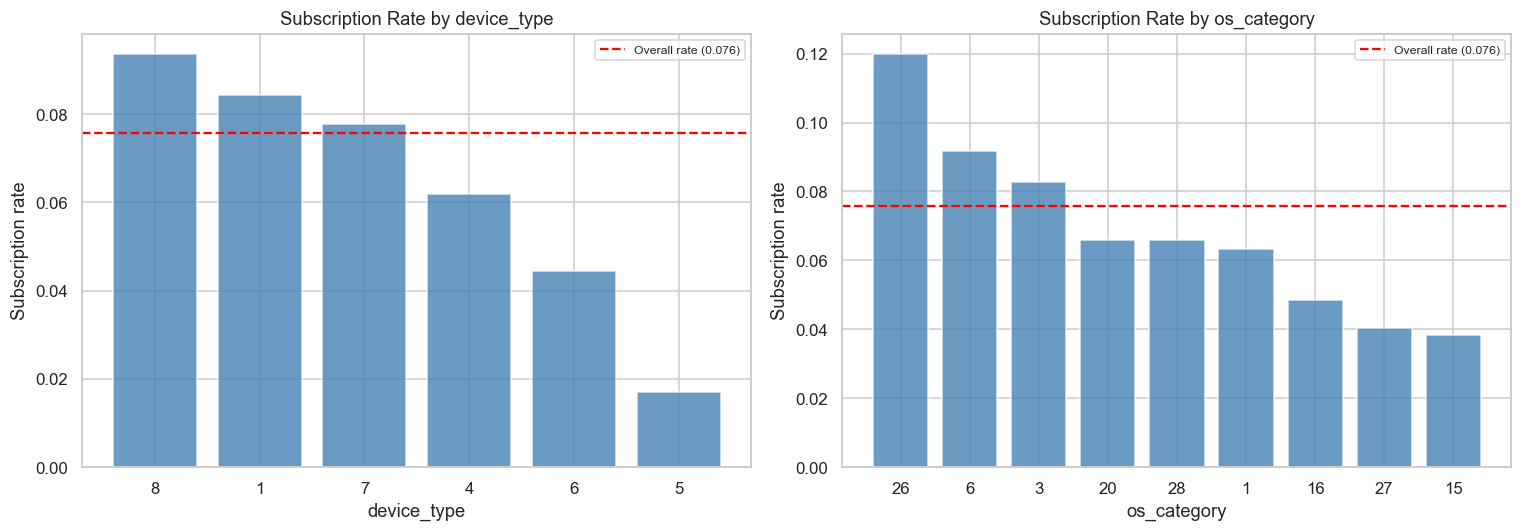

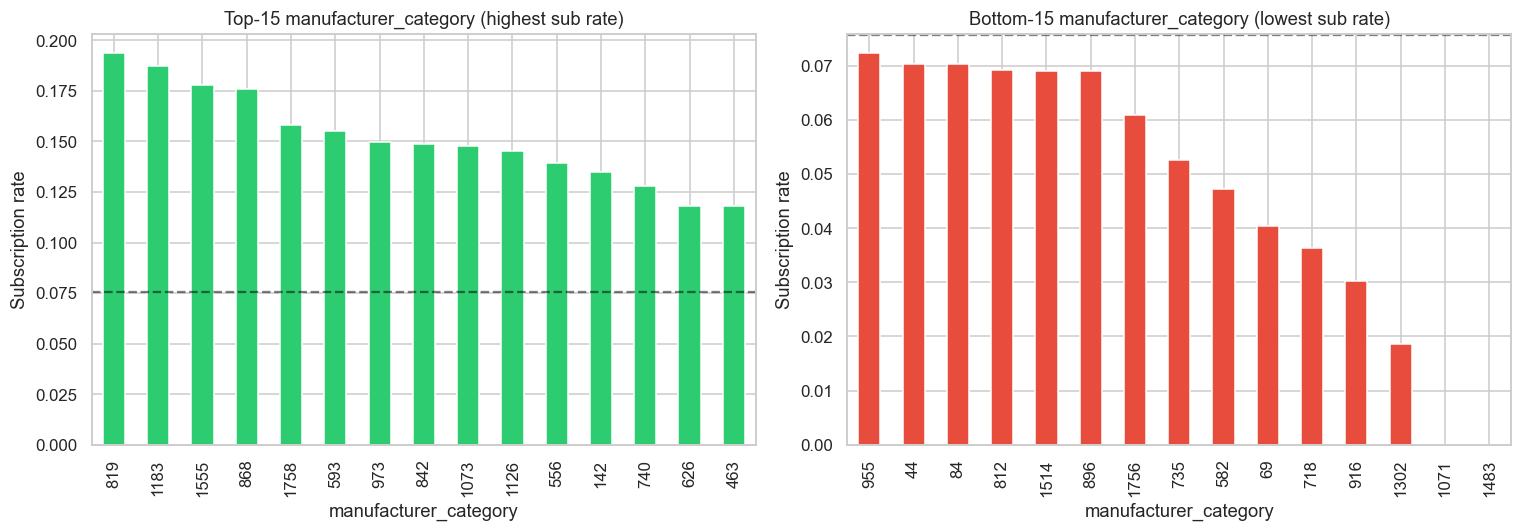

manufacturer_category — categories with ≥50 obs: 55
Subscription rate range: 0.0000 – 0.1935


In [6]:
cat_features = ['device_type', 'os_category', 'manufacturer_category']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(['device_type', 'os_category']):
    ax = axes[i]
    rate = df.groupby(col)['target'].mean().sort_values(ascending=False)
    count = df[col].value_counts()
    # Show only categories with at least 100 observations
    valid = count[count >= 100].index
    rate = rate[rate.index.isin(valid)]

    bars = ax.bar(rate.index.astype(str), rate.values, color='steelblue', alpha=0.8)
    ax.axhline(df['target'].mean(), color='red', linestyle='--', label=f'Overall rate ({df["target"].mean():.3f})')
    ax.set_title(f'Subscription Rate by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Subscription rate')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# manufacturer_category: too many — show top-15 and bottom-15 by subscription rate
manuf_rate = df.groupby('manufacturer_category').agg(
    sub_rate=('target', 'mean'),
    count=('target', 'count')
).query('count >= 50').sort_values('sub_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
manuf_rate.head(15)['sub_rate'].plot(kind='bar', ax=axes[0], color='#2ecc71', title='Top-15 manufacturer_category (highest sub rate)')
manuf_rate.tail(15)['sub_rate'].plot(kind='bar', ax=axes[1], color='#e74c3c', title='Bottom-15 manufacturer_category (lowest sub rate)')
for ax in axes:
    ax.axhline(df['target'].mean(), color='black', linestyle='--', alpha=0.5)
    ax.set_ylabel('Subscription rate')
plt.tight_layout()
plt.show()

print(f'manufacturer_category — categories with ≥50 obs: {len(manuf_rate)}')
print(f'Subscription rate range: {manuf_rate["sub_rate"].min():.4f} – {manuf_rate["sub_rate"].max():.4f}')

### 7. Mutual Information Feature Ranking

**Mutual Information (MI)** captures non-linear dependencies between a feature and the target —
something Pearson/Spearman correlation cannot detect.

We run MI on all features and compare the ranking with our correlation-based ranking.
Features that rank high on MI but low on correlation are candidates for non-linear models.


Computing Mutual Information... (may take ~30 seconds)


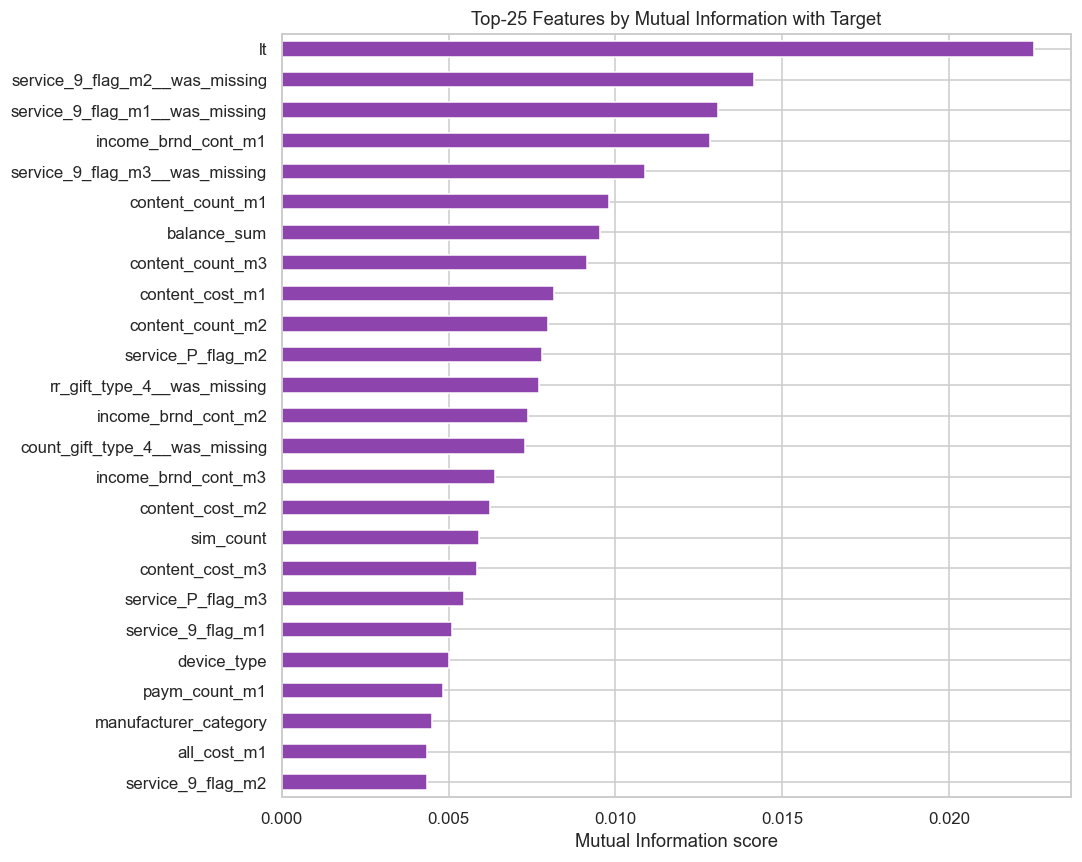


Features ranked much higher by MI than by correlation (non-linear signal):
                                mi_rank  corr_rank  rank_diff
income_brnd_cont_m1                   4        115        111
balance_sum                           7        151        144
rr_gift_type_4__was_missing          12        118        106
income_brnd_cont_m2                  13        249        236
count_gift_type_4__was_missing       14        118        104
income_brnd_cont_m3                  15        231        216
content_cost_m2                      16        148        132
sim_count                            17        326        309
content_cost_m3                      18        201        183
device_type                          21        186        165


In [7]:
X = df[feature_cols].values
y = df['target'].values

print('Computing Mutual Information... (may take ~30 seconds)')
mi_scores = mutual_info_classif(X, y, discrete_features=False, random_state=42, n_neighbors=5)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

# Plot top-25
plt.figure(figsize=(10, 8))
mi_series.head(25).sort_values().plot(kind='barh', color='#8e44ad')
plt.title('Top-25 Features by Mutual Information with Target')
plt.xlabel('Mutual Information score')
plt.tight_layout()
plt.show()

# Compare MI rank vs correlation rank
mi_rank = mi_series.rank(ascending=False).rename('mi_rank')
corr_rank = pb_series.abs().rank(ascending=False).rename('corr_rank')
rank_df = pd.concat([mi_rank, corr_rank], axis=1).dropna().astype(int)
rank_df['rank_diff'] = (rank_df['mi_rank'] - rank_df['corr_rank']).abs()

print('\nFeatures ranked much higher by MI than by correlation (non-linear signal):')
print(rank_df[rank_df['corr_rank'] > 50].nsmallest(10, 'mi_rank')[['mi_rank','corr_rank','rank_diff']].to_string())

### 8. Correlation Heatmap — Top Features

We visualise pairwise Pearson correlations among the **top-25 features by MI score**.
Highly correlated feature pairs (|r| > 0.8) are candidates for deduplication during preprocessing.


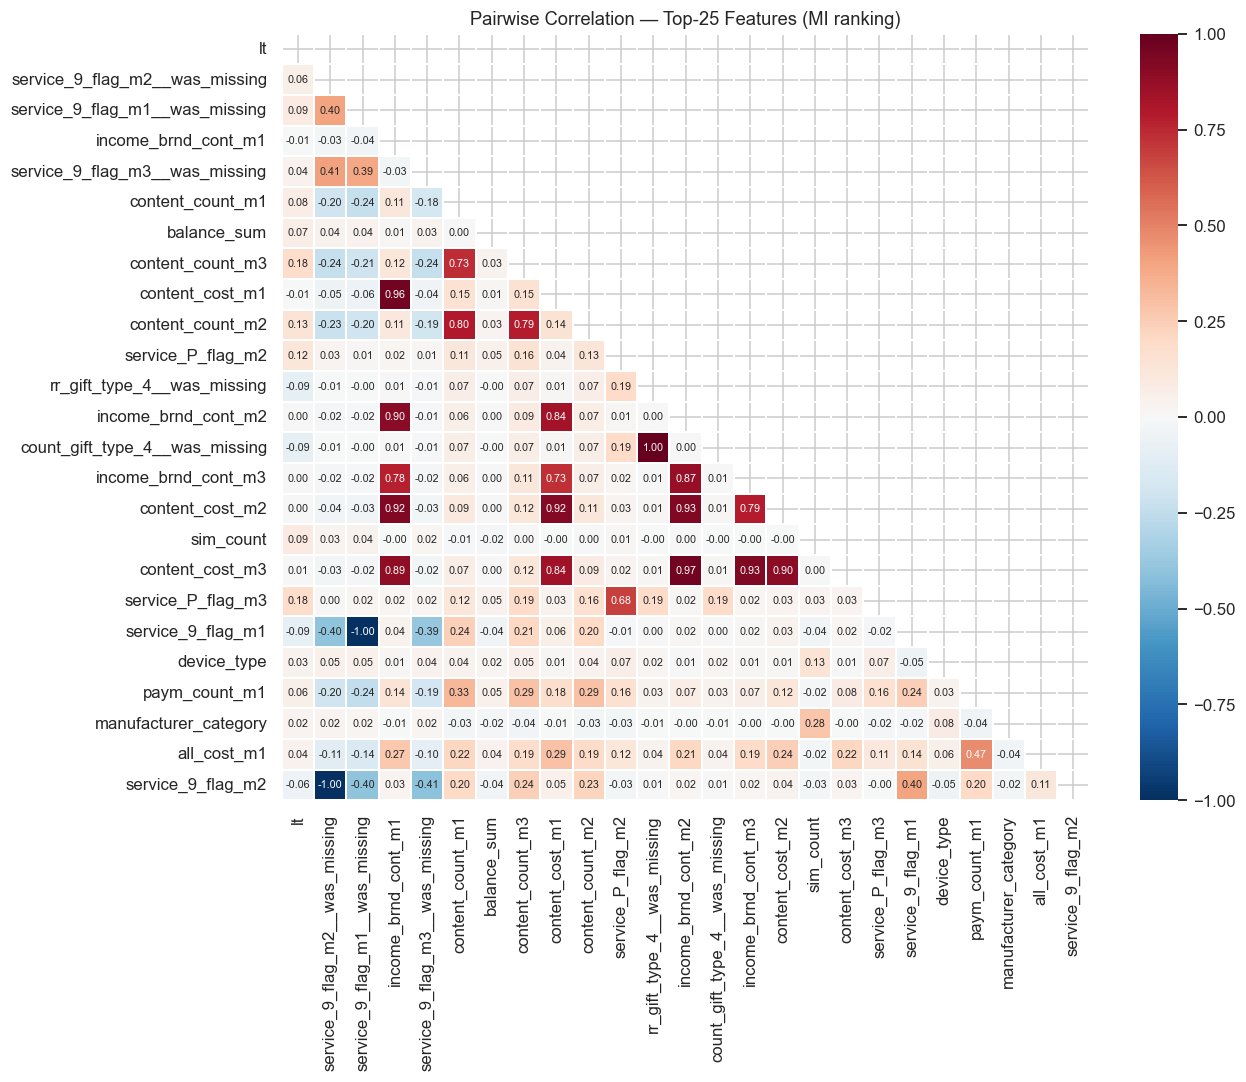

Highly correlated pairs (|r| > 0.8) — candidates for removal:
                     feature_1                      feature_2  correlation
service_9_flag_m2__was_missing              service_9_flag_m2      -1.0000
service_9_flag_m1__was_missing              service_9_flag_m1      -1.0000
           income_brnd_cont_m1                content_cost_m1       0.9643
           income_brnd_cont_m1            income_brnd_cont_m2       0.9018
           income_brnd_cont_m1                content_cost_m2       0.9237
           income_brnd_cont_m1                content_cost_m3       0.8854
              content_count_m1               content_count_m2       0.8018
               content_cost_m1            income_brnd_cont_m2       0.8392
               content_cost_m1                content_cost_m2       0.9162
               content_cost_m1                content_cost_m3       0.8449
   rr_gift_type_4__was_missing count_gift_type_4__was_missing       1.0000
           income_brnd_cont_m2        

In [8]:
top25_mi = mi_series.head(25).index.tolist()

corr_matrix = df[top25_mi].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    linewidths=0.3, annot_kws={'size': 7}
)
plt.title('Pairwise Correlation — Top-25 Features (MI ranking)')
plt.tight_layout()
plt.show()

# Flag highly correlated pairs
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.8:
            high_corr_pairs.append({
                'feature_1': corr_matrix.columns[i],
                'feature_2': corr_matrix.columns[j],
                'correlation': round(r, 4)
            })

if high_corr_pairs:
    print('Highly correlated pairs (|r| > 0.8) — candidates for removal:')
    print(pd.DataFrame(high_corr_pairs).to_string(index=False))
else:
    print('No highly correlated pairs (|r| > 0.8) found among top-25 features.')

### 9. Class Imbalance Deep Dive

The dataset has ~7.6% positive class. This section explores what this means for modeling:
- How does the imbalance affect baseline predictions?
- What threshold / metric should we optimise?


Positive class rate:   0.0757 (7.57%)
Imbalance ratio:       12.2:1  (non-subscribers per subscriber)

Naive classifier (always predict mean) ROC-AUC: 0.5000
  → Any model must beat 0.5 ROC-AUC to be useful



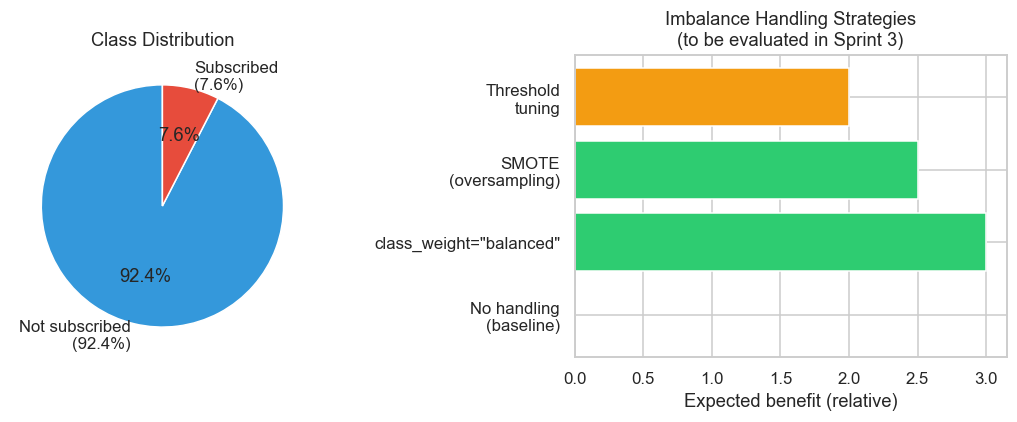

Strategies to address imbalance (Sprint 2-3):
  1. class_weight="balanced" in sklearn models — simplest, no data changes
  2. SMOTE — oversample minority class before training
  3. Optimise classification threshold (default 0.5 is not optimal)
  4. Use ROC-AUC / F1 as primary metric, NOT accuracy


In [9]:
from sklearn.metrics import roc_auc_score

pos_rate = df['target'].mean()
imbalance_ratio = (1 - pos_rate) / pos_rate

print(f'Positive class rate:   {pos_rate:.4f} ({pos_rate*100:.2f}%)')
print(f'Imbalance ratio:       {imbalance_ratio:.1f}:1  (non-subscribers per subscriber)')
print()

# Naive classifier baseline
naive_preds = np.zeros(len(df))
naive_roc = roc_auc_score(df['target'], naive_preds + pos_rate)
print(f'Naive classifier (always predict mean) ROC-AUC: {naive_roc:.4f}')
print(f'  → Any model must beat 0.5 ROC-AUC to be useful')
print()

# Visualise the imbalance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Pie chart
axes[0].pie(
    [1 - pos_rate, pos_rate],
    labels=[f'Not subscribed\n({1-pos_rate:.1%})', f'Subscribed\n({pos_rate:.1%})'],
    colors=['#3498db', '#e74c3c'],
    autopct='%1.1f%%', startangle=90
)
axes[0].set_title('Class Distribution')

# Imbalance handling strategies
strategies = ['No handling\n(baseline)', 'class_weight=\"balanced"', 'SMOTE\n(oversampling)', 'Threshold\ntuning']
expected_impact = [0, 3, 2.5, 2]
axes[1].barh(strategies, expected_impact, color=['#e74c3c','#2ecc71','#2ecc71','#f39c12'])
axes[1].set_xlabel('Expected benefit (relative)')
axes[1].set_title('Imbalance Handling Strategies\n(to be evaluated in Sprint 3)')
plt.tight_layout()
plt.show()

print('Strategies to address imbalance (Sprint 2-3):')
print('  1. class_weight="balanced" in sklearn models — simplest, no data changes')
print('  2. SMOTE — oversample minority class before training')
print('  3. Optimise classification threshold (default 0.5 is not optimal)')
print('  4. Use ROC-AUC / F1 as primary metric, NOT accuracy')

### 10. EDA Summary & Feature Engineering Hypotheses

In [10]:
# Save top features for use in next notebook
top_features_mi   = mi_series.head(30).index.tolist()
top_features_corr = pb_series.head(30).index.tolist()
top_features_union = list(dict.fromkeys(top_features_mi + top_features_corr))  # preserves order, deduplicates

import os
os.makedirs('../data/processed', exist_ok=True)
pd.Series(top_features_union).to_csv('../data/processed/top_features.csv', index=False, header=False)

print(f'Top features saved: {len(top_features_union)} features → ../data/processed/top_features.csv')
print()
print('Top features (union of MI + correlation top-30):')
print(top_features_union)

Top features saved: 45 features → ../data/processed/top_features.csv

Top features (union of MI + correlation top-30):
['lt', 'service_9_flag_m2__was_missing', 'service_9_flag_m1__was_missing', 'income_brnd_cont_m1', 'service_9_flag_m3__was_missing', 'content_count_m1', 'balance_sum', 'content_count_m3', 'content_cost_m1', 'content_count_m2', 'service_P_flag_m2', 'rr_gift_type_4__was_missing', 'income_brnd_cont_m2', 'count_gift_type_4__was_missing', 'income_brnd_cont_m3', 'content_cost_m2', 'sim_count', 'content_cost_m3', 'service_P_flag_m3', 'service_9_flag_m1', 'device_type', 'paym_count_m1', 'manufacturer_category', 'all_cost_m1', 'service_9_flag_m2', 'service_P_flag_m1', 'count_app_5', 'all_cost_m3', 'count_act_type_3', 'is_obl_center', 'service_9_flag_m3', 'data_type_2_m1', 'vol_app_5', 'count_gift_type_1', 'paym_el_count_m1', 'count_sms_source_5', 'data_type_3_m1', 'rr_act_type_3', 'voice_onnet_out_day_work_dur_m3', 'voice_onnet_in_day_work_dur_m3', 'count_gift_type_3', 'rr_gift_

#### EDA Summary

| Finding | Detail | Implication for Feature Engineering |
|---|---|---|
| `lt` strongest negative signal | r = -0.186 | Keep as-is; try log/bin transformation |
| `content_count_m*` family | Consistent positive signal across m1/m2/m3 | Create **trend feature**: m1 - m3 (recent growth) |
| `service_P_flag_m*` family | Consistent negative signal | Create **persistence flag**: active all 3 months? |
| `count_gift_type_3` vs `count_gift_type_1` | Opposite signs | Gift type is discriminating — encode separately |
| `manufacturer_category` | High cardinality, varies by sub rate | Use **target encoding** |
| Missingness indicators (`service_9_flag`) | r up to -0.136 | Already engineered in Sprint 1 |
| MI ≠ Pearson for some features | Non-linear signal exists | Tree-based models will capture it |

#### Feature Engineering Plan (next notebook)
1. **Trend features**: `feature_m1 - feature_m3` for top temporal families
2. **Aggregate features**: sum / mean across m1+m2+m3 for key families
3. **Binary flags**: is this feature ever active across 3 months?
4. **Ratio features**: e.g., content usage / total data usage
5. **Log transformation**: for heavily skewed features (vol_app_*, all_cost_*)
6. **Target encoding**: `manufacturer_category` (high cardinality)
7. **Binning `lt`**: tenure buckets (new / mid / long-term customer)